# Retinal Blood Vessel Segmentation using Machine Learning and Scikit-Learn Pipelines

This notebook implements a high-performance machine learning pipeline for extracting blood vessels from retinal fundus images. 
Compared to the baseline Frangi filter and raw-pixel patch classifiers, this approach utilizes **pixel-wise multi-scale spatial features** combined with a robust **scikit-learn pipeline** and **morphological post-processing**.

## Key Advantages
1. **Convex-Hull Retinal Masking**: Eliminates boundary noise and border false-positives.
2. **Optimal Preprocessing**: Combines double median blurring, local Gaussian background subtraction, and CLAHE to standardize contrast.
3. **Multi-Scale Feature Representation**: Captures local intensity, Gaussian blurs ($\sigma=1, 2, 4$), Sobel gradients, Hessian eigenvalues ($\lambda_1, \lambda_2$ at $\sigma=1, 2$), and three advanced vesselness filter responses (Frangi, Meijering, Sato).
4. **Class Imbalance Mitigation**: Balanced sampling of foreground (vein) and background pixels.
5. **Clean Post-Processing**: Morphological closing and small object removal to ensure contiguous, noise-free vessels.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import cv2
import warnings

from skimage.filters import frangi, meijering, sato, sobel
from skimage.feature import hessian_matrix, hessian_matrix_eigvals
from skimage.morphology import closing, disk, remove_small_objects
from skimage.exposure import equalize_adapthist
from sklearn.metrics import jaccard_score, f1_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Suppress skimage warnings regarding default argument changes
warnings.filterwarnings('ignore', category=FutureWarning)

DATA_DIR = Path.cwd() / 'data'
ORIGINAL_DIR = DATA_DIR / 'original'
LABELS_DIR = DATA_DIR / 'labels'

print(f"Data Directory: {DATA_DIR}")
print(f"Original Images: {len(list(ORIGINAL_DIR.glob('*.ppm')))}")
print(f"Labels: {len(list(LABELS_DIR.glob('*.vk.ppm')))}")

Data Directory: /home/redsec/.djozwik2/university-informatyka-w-medycynie-dno-oka/data
Original Images: 20
Labels: 20


## 1. Load Data & Retinal Mask Functions
We use an advanced retinal masking function that fits a convex hull over the active region of the fundus image. Erode operations clean boundary transitions to prevent the edge-effects that commonly plague pixel classification near borders.

In [29]:
def split_channels(image: np.ndarray):
    """Return R, G, B channels from RGB image."""
    return image[:, :, 0], image[:, :, 1], image[:, :, 2]

def load_image(path: Path) -> np.ndarray:
    return np.array(Image.open(path))

def load_label(path: Path) -> np.ndarray:
    lbl = np.array(Image.open(path))
    return (lbl > 0).astype(np.uint8)

def create_retinal_mask_convex_hull(image_rgb: np.ndarray, erode_kernel_size: int = 20) -> np.ndarray:
    """
    Creates a binary mask covering the eye retina circle using convex hull + morphological closing.
    Erodes slightly to avoid false positives and border artifacts at the boundaries.
    """
    red = image_rgb[:, :, 0]
    red_blur = cv2.medianBlur(red, 9)

    # Adaptive thresholding to segment circular eyeball boundary
    binary = cv2.adaptiveThreshold(
        red_blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        51,  # block size
        15   # constant
    )

    # Find the largest external contour which corresponds to the circular eye region
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.ones_like(binary, dtype=bool)

    largest_contour = max(contours, key=cv2.contourArea)
    hull = cv2.convexHull(largest_contour)

    # Fill the convex hull
    mask = np.zeros_like(binary, dtype=np.uint8)
    cv2.drawContours(mask, [hull], -1, 255, -1)

    # Morphological closing to fill internal gaps
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (erode_kernel_size, erode_kernel_size))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_close)

    # Slightly erode to clean boundary artifacts
    mask = cv2.erode(mask, kernel_close, iterations=1)

    return mask > 0

## 2. Image Preprocessing Pipeline
We extract the green channel and apply an optimized sequence of operations:
1. Median Blur to reduce noise.
2. Gaussian Background Subtraction (subtracting a wide-kernel Gaussian blur from the image) to flatten local illumination gradients.
3. Equalize Adaptive Histogram (CLAHE) inside the mask to enhance blood vessel contrast.

In [30]:
def apply_clahe(green: np.ndarray, mask: np.ndarray, clip_limit: float = 0.015, nbins: int = 256, kernel: int = 128) -> np.ndarray:
    """Apply CLAHE to green channel within the foreground mask."""
    normalized = green.astype(float) / 255.0
    normalized[~mask] = 0
    enhanced = equalize_adapthist(normalized, kernel_size=kernel, clip_limit=clip_limit, nbins=nbins)
    enhanced[~mask] = 0
    return enhanced

def preprocess_image(
    image: np.ndarray, 
    mask: np.ndarray, 
    *, 
    clip_limit: float = 0.015, 
    nbins: int = 256, 
    kernel: int = 128, 
    gauss_size: tuple[int, int] = (51, 51),
    median_blur_size: int = 5
) -> np.ndarray:
    """
    Standardizes image illumination and contrast.
    """
    img = image.astype(np.uint8)
    
    # Remove high-frequency noise
    img = cv2.medianBlur(img, median_blur_size)
    
    # Subtract local background to flatten global lighting
    bg_map = cv2.GaussianBlur(img, gauss_size, 0)
    flat_bg = cv2.subtract(bg_map, img)
    flat_bg = np.clip(flat_bg, 0, 255).astype(np.uint8)
    
    # Smooth remaining noise
    flat_bg = cv2.medianBlur(flat_bg, median_blur_size)
    
    # Enhance local contrast
    clahe = apply_clahe(flat_bg, mask=mask, clip_limit=clip_limit, nbins=nbins, kernel=kernel)
    return clahe

## 3. Multi-Scale Spatial Feature Extraction
Instead of loading raw neighborhood pixels as features (which are sensitive to rotation and easily overfit), we compute invariant hand-crafted spatial filters:
- Equalized Intensity (1 feature)
- Gaussian Blur maps at $\sigma = 1, 2, 4$ (3 features) to capture multi-scale local mean intensity.
- Sobel gradient magnitude (1 feature) for edge information.
- Hessian matrix eigenvalues $\lambda_1, \lambda_2$ at $\sigma=1, 2$ (4 features) to model local curvature and tubular shapes.
- Three state-of-the-art vesselness filter outputs: Frangi, Meijering, and Sato (3 features).

This creates a robust 12-dimensional feature vector for each pixel.

In [31]:
def extract_features(
    img_rgb: np.ndarray, 
    mask: np.ndarray,
    *,
    sigmas_gauss: list[float] = [1, 2, 4],
    sigmas_hessian: list[float] = [1, 2],
    sigmas_vessel: tuple[float] = (0.5, 1, 1.5, 2, 2.5, 3)
) -> np.ndarray:
    """
    Extracts a multi-scale spatial feature map for each pixel in the image.
    Returns a 3D array of shape (H, W, N_features).
    """
    _, green, _ = split_channels(img_rgb)
    enhanced = preprocess_image(green, mask)
    
    feats = [enhanced]
    
    # Gaussian Blur maps
    for sigma in sigmas_gauss:
        blur = cv2.GaussianBlur(enhanced, (0, 0), sigma)
        feats.append(blur)
        
    # Sobel gradient
    feats.append(sobel(enhanced))
    
    # Hessian Eigenvalues
    for sigma in sigmas_hessian:
        H = hessian_matrix(enhanced, sigma=sigma, order='rc')
        eigvals = hessian_matrix_eigvals(H)
        feats.append(eigvals[0])
        feats.append(eigvals[1])
        
    # Frangi vesselness
    v_frangi = frangi(enhanced, sigmas=sigmas_vessel, alpha=0.5, beta=0.5, gamma=None, black_ridges=False)
    feats.append(v_frangi)
    
    # Meijering vesselness
    v_meijering = meijering(enhanced, sigmas=sigmas_vessel, black_ridges=False)
    feats.append(v_meijering)
    
    # Sato vesselness
    v_sato = sato(enhanced, sigmas=sigmas_vessel, black_ridges=False)
    feats.append(v_sato)
    
    return np.stack(feats, axis=-1)

## 4. Balanced Dataset Preparation
Since only ~10% of pixels in the mask are vessels, class imbalance is severe. We sample all positive vessel pixels and match them with an equal number of background pixels (balanced ratio = 1.0) to compile the training set.

In [32]:
def build_training_dataset(
    pairs: list[tuple[Path, Path]], 
    *,
    balance_ratio: float = 1.0,
    random_state: int = 42
) -> tuple[np.ndarray, np.ndarray]:
    """
    Extracts pixel-level features and balances target labels across training images.
    """
    X_all = []
    y_all = []
    
    for idx, (img_path, lbl_path) in enumerate(pairs):
        img = load_image(img_path)
        gold = load_label(lbl_path)
        mask = create_retinal_mask_convex_hull(img)
        
        # Extract spatial feature cube
        X_img = extract_features(img, mask)
        
        y_mask = gold[mask]
        X_mask = X_img[mask]
        
        # Separate indices inside the mask
        vessel_indices = np.where(y_mask == 1)[0]
        bg_indices = np.where(y_mask == 0)[0]
        
        # Sample background pixels to match vessel pixels
        np.random.seed(random_state + idx)
        n_bg_samples = int(len(vessel_indices) * balance_ratio)
        bg_sampled_indices = np.random.choice(bg_indices, size=min(n_bg_samples, len(bg_indices)), replace=False)
        
        selected_indices = np.concatenate([vessel_indices, bg_sampled_indices])
        X_all.append(X_mask[selected_indices])
        y_all.append(y_mask[selected_indices])
        
        print(f"{img_path.name}: {len(vessel_indices)} vessel pixels, sampled {len(bg_sampled_indices)} background pixels.")
        
    return np.concatenate(X_all, axis=0), np.concatenate(y_all, axis=0)

## 5. Model Initialization and Training
We define a scikit-learn pipeline featuring a `StandardScaler` followed by either a `RandomForestClassifier` or `HistGradientBoostingClassifier`.

In [33]:
def make_ml_pipeline(model_type: str = 'rf', random_state: int = 42) -> Pipeline:
    """
    Factory function to initialize the scaling and classification pipeline.
    """
    if model_type == 'rf':
        classifier = RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1)
    elif model_type == 'hgb':
        classifier = HistGradientBoostingClassifier(random_state=random_state)
    elif model_type == "knn":
        classifier = KNeighborsClassifier()
    else:
        raise ValueError(f"Unknown model type: {model_type}")
        
    return Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', classifier)
    ])

# Locate and pair original images with labels
originals = sorted(ORIGINAL_DIR.glob('*.ppm'))
labels = sorted(LABELS_DIR.glob('*.vk.ppm'))
pairs = [(orig, LABELS_DIR / f"{orig.stem}.vk.ppm") for orig in originals if (LABELS_DIR / f"{orig.stem}.vk.ppm").exists()]

# Split into training (first 5) and testing (remaining 15)
train_pairs = pairs[:5]
test_pairs = pairs[5:]

print(f"Building training dataset from {len(train_pairs)} pairs...")
X_train, y_train = build_training_dataset(train_pairs)
print(f"Total training samples: X={X_train.shape}, y={y_train.shape}")

# Initialize and train model
pipeline = make_ml_pipeline(model_type='hgb')
print("Fitting ML Pipeline...")
pipeline.fit(X_train, y_train)
print("Training completed successfully!")

Building training dataset from 5 pairs...
im0001.ppm: 38772 vessel pixels, sampled 38772 background pixels.
im0002.ppm: 23436 vessel pixels, sampled 23436 background pixels.
im0003.ppm: 24401 vessel pixels, sampled 24401 background pixels.
im0004.ppm: 26714 vessel pixels, sampled 26714 background pixels.
im0005.ppm: 44474 vessel pixels, sampled 44474 background pixels.
Total training samples: X=(315594, 12), y=(315594,)
Fitting ML Pipeline...
Training completed successfully!


## 6. Inference and Post-Processing Functions
The model outputs vessel probabilities. We apply a decision threshold to convert probabilities to a binary mask, then run morphological closing (to bridge gaps) and `remove_small_objects` (to clean up salt-and-pepper noise).

In [34]:
def predict_full_image(
    pipeline: Pipeline,
    image_rgb: np.ndarray,
    mask: np.ndarray,
    *,
    threshold: float = 0.5,
    closing_disk_size: int = 1,
    min_object_size: int = 40
) -> tuple[np.ndarray, np.ndarray]:
    """
    Predicts vessel mask for a full image and applies morphological cleaning.
    Returns (pred_binary, prob_map).
    """
    # 1. Feature extraction
    X_img = extract_features(image_rgb, mask)
    X_mask = X_img[mask]
    
    # 2. Pipeline prediction ofpred probability
    probs = pipeline.predict_proba(X_mask)[:, 1]
    
    prob_map = np.zeros(mask.shape)
    prob_map[mask] = probs
    
    # 3. Decision thresholding
    pred = prob_map > threshold
    
    # 4. Morphological post-processing
    pred_cleaned = closing(pred, disk(closing_disk_size))
    pred_cleaned = remove_small_objects(pred_cleaned, min_size=min_object_size)
    pred_cleaned = (pred_cleaned * mask).astype(np.uint8)
    
    return pred_cleaned, prob_map

def evaluate(pred: np.ndarray, gold: np.ndarray, mask: np.ndarray) -> dict:
    """Compute evaluation metrics inside the retinal mask area."""
    p_flat = pred[mask].ravel()
    g_flat = gold[mask].ravel()
    
    tn, fp, fn, tp = confusion_matrix(g_flat, p_flat).ravel()
    
    sensitivity = tp / max(1, tp + fn)
    specificity = tn / max(1, tn + fp)
    
    return {
        "accuracy": accuracy_score(g_flat, p_flat),
        "f1": f1_score(g_flat, p_flat, zero_division=0),
        "iou": jaccard_score(g_flat, p_flat, zero_division=0),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn)
    }

## 7. Pipeline Evaluation on Test Set
We evaluate the trained model on the 15 unseen test images. Accuracy, F1-Score, and IoU are computed specifically inside the valid retinal mask region.

In [35]:
test_results = []
for orig_path, lbl_path in test_pairs:
    img = load_image(orig_path)
    gold = load_label(lbl_path)
    mask = create_retinal_mask_convex_hull(img)
    
    # Inference
    pred, prob_map = predict_full_image(pipeline, img, mask)
    
    # Evaluate
    metrics = evaluate(pred, gold, mask)
    test_results.append({
        "image_id": orig_path.stem,
        **metrics
    })
    print(f"{orig_path.stem}: F1={metrics['f1']:.4f}  IoU={metrics['iou']:.4f}  Acc={metrics['accuracy']:.4f}  Sen={metrics['sensitivity']:.4f}  Spe={metrics['specificity']:.4f}")

df = pd.DataFrame(test_results)
print(f"\n{'='*40}")
print(f"Mean Test Accuracy inside mask:    {df['accuracy'].mean():.4f}")
print(f"Mean Test F1-Score inside mask:    {df['f1'].mean():.4f}")
print(f"Mean Test IoU (Jaccard) inside mask: {df['iou'].mean():.4f}")
print(f"Mean Test Sensitivity inside mask: {df['sensitivity'].mean():.4f}")
print(f"Mean Test Specificity inside mask: {df['specificity'].mean():.4f}")
print(f"{'='*40}")

im0044: F1=0.5705  IoU=0.3991  Acc=0.8399  Sen=0.7720  Spe=0.8507
im0077: F1=0.6775  IoU=0.5123  Acc=0.8581  Sen=0.8443  Spe=0.8610
im0081: F1=0.6652  IoU=0.4984  Acc=0.8499  Sen=0.7959  Spe=0.8624
im0082: F1=0.6386  IoU=0.4691  Acc=0.8535  Sen=0.7793  Spe=0.8683
im0139: F1=0.6427  IoU=0.4736  Acc=0.8239  Sen=0.7727  Spe=0.8371
im0162: F1=0.6795  IoU=0.5146  Acc=0.8955  Sen=0.7286  Spe=0.9254
im0163: F1=0.7404  IoU=0.5878  Acc=0.9105  Sen=0.8351  Spe=0.9241
im0235: F1=0.7378  IoU=0.5845  Acc=0.9008  Sen=0.7383  Spe=0.9387
im0236: F1=0.6803  IoU=0.5155  Acc=0.8647  Sen=0.8036  Spe=0.8780
im0239: F1=0.6791  IoU=0.5142  Acc=0.8726  Sen=0.7958  Spe=0.8883
im0240: F1=0.6806  IoU=0.5158  Acc=0.8656  Sen=0.8049  Spe=0.8787
im0255: F1=0.6648  IoU=0.4980  Acc=0.8619  Sen=0.7624  Spe=0.8837
im0291: F1=0.7646  IoU=0.6189  Acc=0.9621  Sen=0.7143  Spe=0.9855
im0319: F1=0.5474  IoU=0.3768  Acc=0.9056  Sen=0.6834  Spe=0.9258
im0324: F1=0.6394  IoU=0.4700  Acc=0.9008  Sen=0.6651  Spe=0.9367

Mean Test

## 8. Visual Results Comparison
We plot predictions, probability maps, and gold standard annotations side-by-side to visually assess segmentation quality.

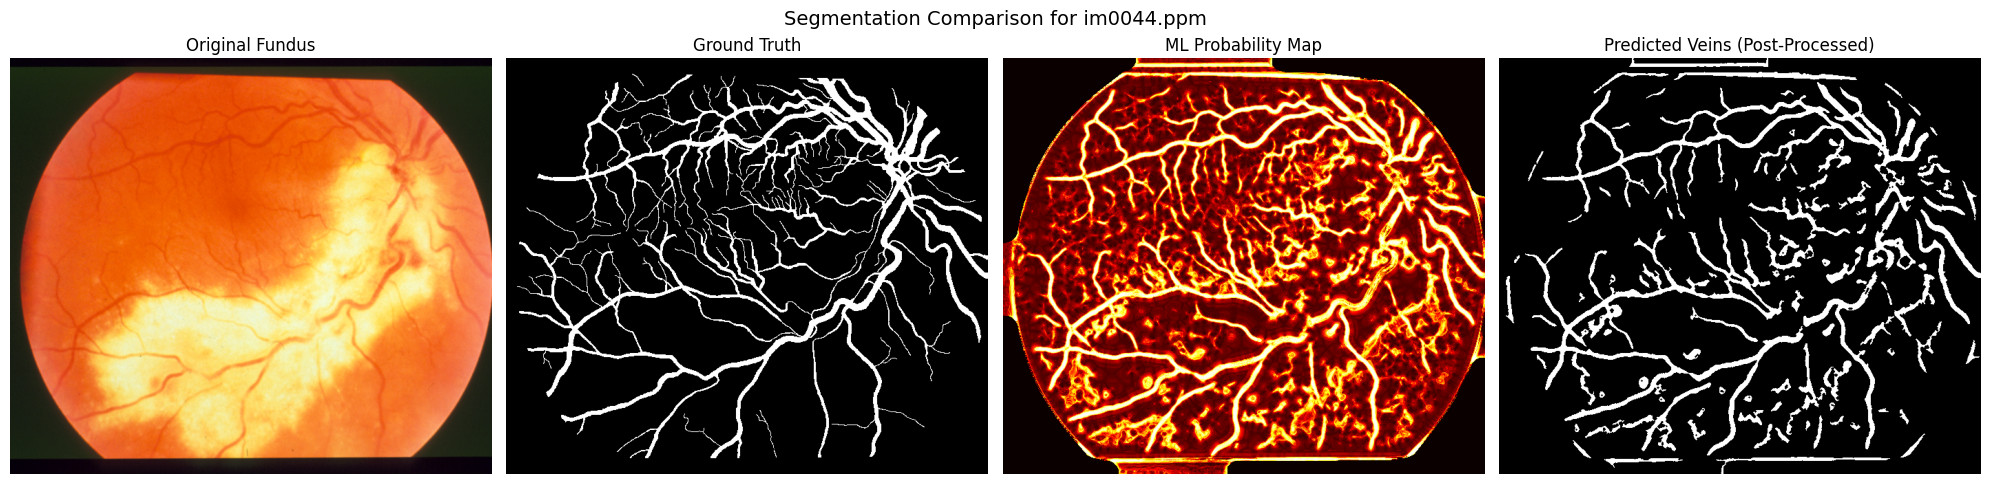

In [37]:
def show_results(img_path, lbl_path, pipeline):
    img = load_image(img_path)
    gold = load_label(lbl_path)
    mask = create_retinal_mask_convex_hull(img)
    
    pred, prob_map = predict_full_image(pipeline, img, mask, threshold=0.7)
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(img)
    axes[0].set_title("Original Fundus")
    axes[0].axis("off")
    
    axes[1].imshow(gold, cmap="gray")
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")
    
    axes[2].imshow(prob_map, cmap="hot")
    axes[2].set_title("ML Probability Map")
    axes[2].axis("off")
    
    axes[3].imshow(pred, cmap="gray")
    axes[3].set_title("Predicted Veins (Post-Processed)")
    axes[3].axis("off")
    
    plt.suptitle(f"Segmentation Comparison for {img_path.name}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualize a sample from the test set
show_results(test_pairs[0][0], test_pairs[0][1], pipeline)